In [2]:
%load_ext autoreload
%autoreload 2

from project_root import PROJECT_ROOT
from scripts.model_serialization import load_model

import torchvision as tv
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import enlighten
from pathlib import Path
from tqdm import tqdm

torch.autograd.set_grad_enabled(False)

pbar_manager = enlighten.get_manager()

In [2]:
#########################################
# Load trained models
USE_JIT = True
cpu = torch.device("cpu")

ext = ".ptc" if USE_JIT else ".pth"
model_instant = load_model(
    PROJECT_ROOT / ("models/identity/freeze10/dense121_c5_identity" + ext)
)
model_instant.eval()

model_sequence = load_model(PROJECT_ROOT / ("models/identity/gru_v2/zoo_id_gru" + ext))
model_sequence = model_sequence.to(cpu)
model_sequence.eval()

RecursiveScriptModule(
  original_name=StateModelWithTransforms
  (model): RecursiveScriptModule(
    original_name=ZooIdGruModel
    (features): RecursiveScriptModule(
      original_name=Sequential
      (conv0): RecursiveScriptModule(original_name=Conv2d)
      (norm0): RecursiveScriptModule(original_name=BatchNorm2d)
      (relu0): RecursiveScriptModule(original_name=ReLU)
      (pool0): RecursiveScriptModule(original_name=MaxPool2d)
      (denseblock1): RecursiveScriptModule(
        original_name=_DenseBlock
        (denselayer1): RecursiveScriptModule(
          original_name=_DenseLayer
          (norm1): RecursiveScriptModule(original_name=BatchNorm2d)
          (relu1): RecursiveScriptModule(original_name=ReLU)
          (conv1): RecursiveScriptModule(original_name=Conv2d)
          (norm2): RecursiveScriptModule(original_name=BatchNorm2d)
          (relu2): RecursiveScriptModule(original_name=ReLU)
          (conv2): RecursiveScriptModule(original_name=Conv2d)
        )
    

/home/dherrera/data/elephants/identity/dataset/mix/train/01_Chandra/ZAG-ELP-CAM-016-25.01.2025-060029-100029_00000000_img.jpg


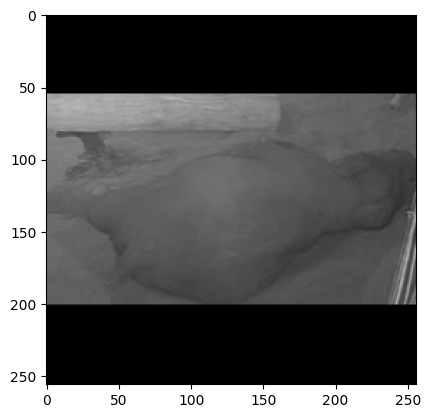

In [3]:
ds_path = Path("/home/dherrera/data/elephants/identity/dataset/train")
gt_class = "01_Chandra"

files = sorted(list((ds_path / gt_class).glob("*.jpg")))
# file = files[10]
file = Path(
    "/home/dherrera/data/elephants/identity/dataset/mix/train/01_Chandra/ZAG-ELP-CAM-016-25.01.2025-060029-100029_00000000_img.jpg"
)
print(file)
im: np.ndarray = cv2.imread(file)
imt = torch.from_numpy(im.astype(np.float32) / 255).permute([2, 0, 1])

plt.imshow(im)

In [4]:
result: torch.Tensor = model_instant.forward(imt[None, :, :, :])
print(f"Logits: {result.numpy()}")

Logits: [[-0.24185155 -0.46711913  0.59103954 -0.03844196  0.0978432 ]]


In [5]:
input = imt[None, None, :, :, :]
# input = input[[0,0],:,:,:]
print(f"{input.shape=}")
result = model_sequence.forward(input)
print(f"{result['gru_state'].shape=}")
print(f"Logits: {result['logits'].numpy()}")

input.shape=torch.Size([1, 1, 3, 256, 256])
result['gru_state'].shape=torch.Size([3, 1, 128])
Logits: [[[ 0.943833   -1.4298042  -1.1426129   0.97619295  0.7120806 ]]]


{'01_Chandra': 0, '02_Indi': 1, '03_Fahra': 2, '04_Panang': 3, '05_Thai': 4}


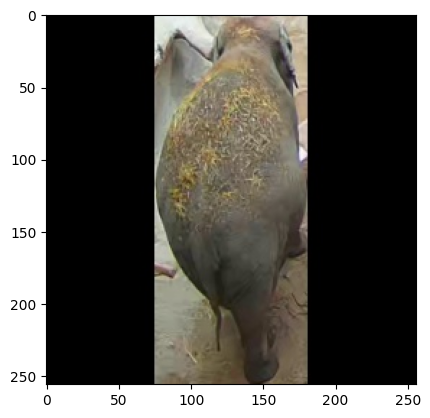

In [6]:
ds_transforms = tv.transforms.Compose([tv.transforms.PILToTensor()])
dataset_test = tv.datasets.ImageFolder(
    "/home/dherrera/data/elephants/identity/dataset/mix/val", ds_transforms
)
print(dataset_test.class_to_idx)
ds_item, target = dataset_test[0]
if isinstance(ds_item, torch.Tensor):
    im = ds_item.permute([1, 2, 0]).numpy()
    im = im - np.mean(im)
    im = im - np.min(im)
    im = im / np.max(np.abs(im))
else:
    im = ds_item
plt.imshow(im)

In [7]:
###############################
# Eval instant model
total = 0
correct = 0
for i in tqdm(range(0, len(dataset_test))):
    ds_item, target = dataset_test[i]
    result = model_instant.forward(ds_item[torch.newaxis, ...])
    y = torch.argmax(result).item()

    total += 1
    if y == target:
        correct += 1
accuracy = correct / total
print(f"Accuracy: {correct}/{total}={accuracy:%}")

100%|██████████| 187/187 [00:04<00:00, 38.35it/s]

Accuracy: 136/187=72.727273%


In [8]:
###############################
# Eval sequence model with single image
total = 0
correct = 0
for i in tqdm(range(0, len(dataset_test))):
    ds_item, target = dataset_test[i]
    result = model_sequence.forward(ds_item[torch.newaxis, torch.newaxis, ...])
    result = result["logits"][0, 0]
    y = torch.argmax(result).item()

    total += 1
    if y == target:
        correct += 1
accuracy = correct / total
print(f"Accuracy: {correct}/{total}={accuracy:%}")

  0%|          | 0/187 [00:00<?, ?it/s]

100%|██████████| 187/187 [00:05<00:00, 36.22it/s]

Accuracy: 136/187=72.727273%


In [9]:
###############################
# Eval sequence model with 2 images
from zoo_vision.training.identity.identity_sequence_dataset import (
    IdentitySequenceDataset,
)

ds_seq = IdentitySequenceDataset(4, dataset_test)

total = 0
correct = 0
for i in tqdm(range(0, len(ds_seq))):
    ds_item, target = ds_seq[i]
    result = model_sequence.forward(ds_item[torch.newaxis, ...])
    result = result["logits"][0, -1]
    y = torch.argmax(result).item()

    total += 1
    if y == target:
        correct += 1
accuracy = correct / total
print(f"Accuracy: {correct}/{total}={accuracy:%}")

100%|██████████| 187/187 [00:23<00:00,  7.84it/s]

Accuracy: 167/187=89.304813%


In [10]:
######################################################
# Second notebook?
%load_ext autoreload
%autoreload 2
from model import ZooIdGruModel
import torchvision as tv

# import torchinfo
import torch

torch.autograd.set_grad_enabled(False)

cpu = torch.device("cpu")
gpu = torch.device("cuda")

backbone = tv.models.densenet121(
    num_classes=5,
)
model = ZooIdGruModel(backbone.features).to(gpu)
del backbone
# torchinfo.summary(model, input_size=(2, 10, 3, 1000, 2000))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
##############################################
# Test that passing images sequentially
# is the same as passing images in bulk
batch_count = 2
time_count = 10
images = torch.rand((batch_count, time_count, 3, 256, 256), device=gpu)

print("Sequence pass")
out = model.forward(images)
res1 = out["logits"].to(cpu)

print("Individual pass")
res2_t = []
h0 = torch.zeros(
    (model.gru_layer_count, batch_count, model.gru_feature_count), device=gpu
)
for t in range(10):
    images_t = images[:, [t], :, :]
    out = model.forward(images_t, h0)
    h0 = out["gru_state"]
    res2_t.append(out["logits"])
res2 = torch.cat(res2_t, dim=1)
res2 = res2.to(cpu)

assert res1.shape == res2.shape
diff = (res1 - res2).abs().max()
print(diff)

Sequence pass
Individual pass
tensor(0.0973)


In [ ]:
def entropy(x):
    return -np.sum(x * np.log(x + np.finfo(float).eps))


a = np.array([0.25, 0.25, 0.25, 0.25])
b = np.array([0.4, 0.2, 0.2, 0.2])
b = np.array([1.0, 0.0, 0.0, 0.0])
print(entropy(a), entropy(b))

1.3862943611198897 -2.2204460492503128e-16
